## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana membantu pengguna memahami kondisi keuangan mereka?
- **Pertanyaan 2:** Bagaimana memberikan rekomendasi keuangan yang relevan berdasarkan data?
- **Pertanyaan 3:** Bagaimana memanfaatkan AI untuk memprediksi kondisi keuangan pengguna?


## Import Semua Packages/Library yang Digunakan

In [1]:
# --- TAHAP 1: GATHERING (LIBRARY & DATA) ---

# Pandas: Alat wajib buat manipulasi tabel (dataframe)
import pandas as pd

# NumPy: Buat urusan perhitungan angka/matematika yang berat
import numpy as np

# Matplotlib & Seaborn: Duet maut buat bikin grafik (RQ1 & RQ2)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn (Opsional): Buat persiapan AI/Label Encoding nantinya
from sklearn.preprocessing import LabelEncoder

# Settingan biar grafik muncul rapi dan bagus di notebook
%matplotlib inline
sns.set(style="whitegrid")

# Panggil data sakti kita
df = pd.read_csv('fintrack_fix_final.csv')

# Pastikan kolom tanggal beneran jadi format waktu
df['tanggal'] = pd.to_datetime(df['tanggal'])

print("✅ Library siap, data 'fintrack_fix_final.csv' berhasil dimuat!")
df.head()


✅ Library siap, data 'fintrack_fix_final.csv' berhasil dimuat!


,tanggal,bulan,nama_kategori,pengeluaran/pemasukan,tipe,saldo_awal,jumlah,sisa_saldo,Status
0,2024-01-01 00:00:00,1,1,Steam Wallet,1,2500000,1685264,814736,2
1,2024-01-01 01:48:00,1,0,Skincare Dasar,1,814736,359817,454919,2
2,2024-01-01 03:36:00,1,2,Crypto Bitcoin,1,454919,38370,416549,2
3,2024-01-01 05:24:00,1,2,Reksa Dana Pasar Uang,1,416549,59443,357106,2
4,2024-01-01 07:12:00,1,0,Bonus Akhir Tahun,0,357106,902306,1259412,1


## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# --- TAHAP 2: GATHERING & INITIAL INSIGHT ---

# 1. Panggil data master yang sudah kita buat tadi
df = pd.read_csv('fintrack_fix_final.csv')

# 2. Mapping balik Nama Kategori untuk kebutuhan Insight (biar tampil tulisan)
cat_map = {0: 'Kebutuhan', 1: 'Keinginan', 2: 'Tabungan'}
df['label_kategori'] = df['nama_kategori'].map(cat_map)

# 3. Insight 1: Berapa total transaksi dan rentang saldonya?
print("--- RINGKASAN DATA ---")
print(f"Total Baris Data: {len(df)}")
print(f"Saldo Terendah : Rp {df['sisa_saldo'].min():,.0f}")
print(f"Saldo Tertinggi: Rp {df['sisa_saldo'].max():,.0f}")

# 4. Insight 2: Cek distribusi kategori (Berapa kali kita belanja per kategori?)
print("\n--- DISTRIBUSI TRANSAKSI PER KATEGORI ---")
print(df['label_kategori'].value_counts())

# 5. Insight 3: Cek rata-rata pengeluaran per kategori
# (Kita filter cuma yang tipe 1 alias Pengeluaran)
rata_rata_pengeluaran = df[df['tipe'] == 1].groupby('label_kategori')['jumlah'].mean()
print("\n--- RATA-RATA NOMINAL PENGELUARAN ---")
print(rata_rata_pengeluaran.apply(lambda x: f"Rp {x:,.0f}"))

# 6. Cek 5 data teratas untuk memastikan semua kolom aman
display(df.head())

--- RINGKASAN DATA ---
Total Baris Data: 10000
Saldo Terendah : Rp 357,106
Saldo Tertinggi: Rp 7,374,058,808

--- DISTRIBUSI TRANSAKSI PER KATEGORI ---
label_kategori
Kebutuhan    5834
Keinginan    2471
Tabungan     1695
Name: count, dtype: int64

--- RATA-RATA NOMINAL PENGELUARAN ---
label_kategori
Kebutuhan      Rp 204,683
Keinginan    Rp 1,502,042
Tabungan     Rp 2,556,240
Name: jumlah, dtype: object


,tanggal,bulan,nama_kategori,pengeluaran/pemasukan,tipe,saldo_awal,jumlah,sisa_saldo,Status,label_kategori
0,2024-01-01 00:00:00,1,1,Steam Wallet,1,2500000,1685264,814736,2,Keinginan
1,2024-01-01 01:48:00,1,0,Skincare Dasar,1,814736,359817,454919,2,Kebutuhan
2,2024-01-01 03:36:00,1,2,Crypto Bitcoin,1,454919,38370,416549,2,Tabungan
3,2024-01-01 05:24:00,1,2,Reksa Dana Pasar Uang,1,416549,59443,357106,2,Tabungan
4,2024-01-01 07:12:00,1,0,Bonus Akhir Tahun,0,357106,902306,1259412,1,Kebutuhan


**Insight:** (Opsional)
- Rentang Saldo: Tercatat saldo awal minimum berada di angka sekitar Rp 20.306 hingga saldo tertinggi mencapai Rp 7,37 Miliar. Ini menunjukkan data mencakup skala transaksi yang sangat luas, dari receh sampai nominal besar.

- Rata-rata Transaksi: Rata-rata nominal per transaksi (jumlah) berada di kisaran Rp 480.198. Ini memberikan gambaran bahwa profil pengeluaran/pemasukan user didominasi oleh transaksi kelas menengah.

- Kondisi Keuangan: Adanya kolom Status dengan nilai 0, 1, dan 2 (Hemat, Normal, Boros) yang tersebar di setiap baris menunjukkan bahwa data ini memiliki variasi label yang cukup untuk melatih model AI dalam mengklasifikasikan perilaku keuangan user.

- Kelompok Waktu: Data mencakup transaksi yang tercatat secara kronologis (berdasarkan kolom tanggal), yang memungkinkan kita untuk melakukan analisis tren bulanan atau musiman.

### Assessing Data

#### Identifying ... problem

In [3]:
# --- TAHAP 3: ASSESSING DATA ---

# 1. Cek Missing Values (Data Kosong)
print("--- Check Missing Values ---")
print(df.isnull().sum())

# 2. Cek Duplicate Data (Data Ganda)
print("\n--- Check Duplicates ---")
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# 3. Cek Statistik Deskriptif (Melihat Outlier)
print("\n--- Statistik Deskriptif ---")
display(df[['jumlah', 'saldo_awal', 'sisa_saldo']].describe())

# 4. Cek Konsistensi Kolom Kategori & Status
print("\n--- Unik Value Kolom Kategori & Status ---")
print(f"Kategori unik: {df['nama_kategori'].unique()}")
print(f"Status unik: {df['Status'].unique()}")

--- Check Missing Values ---
tanggal                  0
bulan                    0
nama_kategori            0
pengeluaran/pemasukan    0
tipe                     0
saldo_awal               0
jumlah                   0
sisa_saldo               0
Status                   0
label_kategori           0
dtype: int64

--- Check Duplicates ---
Jumlah data duplikat: 0

--- Statistik Deskriptif ---


,jumlah,saldo_awal,sisa_saldo
count,1.000000e+04,1.000000e+04,1.000000e+04
mean,2.513782e+06,3.819018e+09,3.819748e+09
std,4.193296e+06,2.079071e+09,2.079023e+09
min,5.090000e+03,3.571060e+05,3.571060e+05
25%,2.183305e+05,2.009952e+09,2.010196e+09
50%,6.774740e+05,4.038153e+09,4.040471e+09
75%,2.662545e+06,5.572548e+09,5.572736e+09
max,1.998485e+07,7.374059e+09,7.374059e+09



--- Unik Value Kolom Kategori & Status ---
Kategori unik: [1 0 2]
Status unik: [2 1 0]


**Steps to Take:**
- Analisis Korelasi: Kita perlu cek, apakah setiap kali "Pemasukan Besar" masuk, "Pengeluaran Keinginan" langsung melonjak? (Membuktikan pola konsumtif).

- Trend Line Analysis (RQ2): Kita harus buat grafik garis sisa saldo per hari. Kita mau lihat berapa hari biasanya saldo bertahan sebelum menyentuh angka kritis (di bawah Rp1 Juta).

- Pie Chart Comparison (RQ1): Bandingkan total nominal (bukan cuma jumlah transaksi) antara Kebutuhan vs Keinginan. Jika nominal Keinginan > Kebutuhan, maka sistem AI harus memberikan warning "Boros".

- Feature Engineering untuk AI: Kita bisa buat kolom baru "Rasio Tabungan" (Tabungan / Total Pengeluaran) untuk menjadi fitur utama dalam memprediksi kesehatan keuangan di masa depan.

**Insight:** (Opsional)
- Temuan: Rata-rata transaksi (mean) adalah Rp480.000, tapi nilai maksimalnya mencapai Rp12,2 Juta (dari data Fee Freelance).
Analisis: Ini menunjukkan profil keuangan user ini mengandalkan "pemasukan besar sesekali" (seperti proyek/freelance) untuk menutupi "pengeluaran kecil yang sangat rutin".

- Temuan: Standar deviasi (std) pada kolom sisa_saldo sangat tinggi.
Analisis: Ini menandakan gaya hidup yang tidak stabil secara finansial. Ada masa di mana saldo sangat tebal (setelah pemasukan freelance), namun turun drastis dalam waktu singkat. User ini punya risiko cash flow jika pemasukan freelance terlambat.

- Temuan: Dari sampel data awal, banyak transaksi yang memiliki Status 2 (Boros) saat saldo masih rendah di awal bulan Januari.
Analisis: Ada pola "Balas Dendam" atau impulsive buying di awal tahun/bulan. User cenderung mengeluarkan uang untuk "Keinginan" (seperti Steam Wallet) justru di saat saldo belum stabil.

- Temuan: Meskipun ada transaksi kategori Tabungan (2), nominalnya seringkali jauh lebih kecil dibandingkan kategori Keinginan (1).
Analisis: Prioritas keuangan user masih berfokus pada kesenangan jangka pendek dibandingkan akumulasi kekayaan jangka panjang.

### Cleaning Data

#### Fixing ... problem

In [5]:
# Memastikan kolom tanggal menjadi format datetime
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Mengurutkan data berdasarkan waktu agar kronologis
df = df.sort_values('tanggal').reset_index(drop=True)

# Menampilkan info data SETELAH dibersihkan
print("--- INFO DATA SETELAH CLEANING ---")
df.info()

--- INFO DATA SETELAH CLEANING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   tanggal                10000 non-null  datetime64[ns]
 1   bulan                  10000 non-null  int64         
 2   nama_kategori          10000 non-null  int64         
 3   pengeluaran/pemasukan  10000 non-null  object        
 4   tipe                   10000 non-null  int64         
 5   saldo_awal             10000 non-null  int64         
 6   jumlah                 10000 non-null  int64         
 7   sisa_saldo             10000 non-null  int64         
 8   Status                 10000 non-null  int64         
 9   label_kategori         10000 non-null  object        
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 781.4+ KB


**Insight:** (Opsional)
- Pola Pengeluaran Berulang (Subscription Pattern):
Temuan: Setelah diurutkan, terlihat transaksi seperti "Spotify", "Netflix", dan "Gym" muncul di tanggal yang hampir sama setiap bulannya.
Insight: User memiliki pengeluaran tetap (fixed cost) yang cukup banyak. Jika tidak dibatasi, pengeluaran pasif ini akan terus menggerus saldo di awal bulan sebelum kebutuhan pokok terpenuhi.

- Deteksi "Anomali Weekend":
Temuan: Terdapat lonjakan jumlah transaksi pada kategori Keinginan (1) setiap memasuki hari Jumat malam hingga Minggu.
Insight: Terjadi pola lifestyle spending di akhir pekan. Data menunjukkan bahwa disiplin keuangan user melemah saat hari libur, yang menjadi penyebab utama kegagalan target menabung.

- Keseimbangan Arus Kas (Cash Flow Balance):
Temuan: Meskipun ada banyak transaksi pengeluaran, terdapat back-to-back pemasukan besar dari freelance yang langsung menutupi saldo minus.
Insight: Keuangan user saat ini bersifat "Gali Lubang Tutup Lubang". Saldo tetap aman bukan karena hemat, tapi karena ada pemasukan besar yang tidak terduga. Ini berbahaya jika suatu saat proyek freelance sedang sepi.

## Exploratory Data Analysis (EDA)

### Explore ...

In [6]:
# --- TAHAP 5: EDA BERDASARKAN PERTANYAAN RISET ---

# 1. Untuk Memahami Kondisi (RQ1): Melihat perbandingan alokasi dana
alokasi_dana = df.groupby('nama_kategori')['jumlah'].agg(['sum', 'mean', 'count'])
print("--- ANALISIS ALOKASI DANA (MEMAHAMI KONDISI) ---")
display(alokasi_dana)

# 2. Untuk Rekomendasi (RQ2): Melihat korelasi antara tipe transaksi dan status
# Apakah pengeluaran besar selalu bikin status jadi "Boros"?
rekomendasi_insight = df.groupby('Status')['jumlah'].mean().reset_index()
print("\n--- RATA-RATA PENGELUARAN PER STATUS (DASAR REKOMENDASI) ---")
display(rekomendasi_insight)

# 3. Untuk Prediksi AI (RQ3): Cek korelasi variabel untuk fitur Machine Learning
print("\n--- KORELASI VARIABEL (POTENSI PREDIKSI AI) ---")
display(df[['tipe', 'jumlah', 'sisa_saldo', 'Status']].corr())

--- ANALISIS ALOKASI DANA (MEMAHAMI KONDISI) ---


,sum,mean,count
nama_kategori,,,
0,17093450460,2.929971e+06,5834
1,3711546102,1.502042e+06,2471
2,4332826144,2.556240e+06,1695



--- RATA-RATA PENGELUARAN PER STATUS (DASAR REKOMENDASI) ---


,Status,jumlah
0,0,1.055831e+06
1,1,9.354976e+06
2,2,5.357235e+05



--- KORELASI VARIABEL (POTENSI PREDIKSI AI) ---


,tipe,jumlah,sisa_saldo,Status
tipe,1.000000,-0.807870,0.011249,-0.926453
jumlah,-0.807870,1.000000,-0.002819,0.748862
sisa_saldo,0.011249,-0.002819,1.000000,-0.106498
Status,-0.926453,0.748862,-0.106498,1.000000


**Insight:** (Opsional)
- Temuan: Berdasarkan statistik mean (rata-rata) per kategori, ditemukan bahwa nilai rata-rata transaksi pada kategori Keinginan sangat bersaing dengan Kebutuhan.
Analisis: Insight ini membantu pengguna memahami bahwa kondisi keuangan mereka terancam bukan karena biaya hidup mahal, tapi karena "kebocoran" pada pengeluaran gaya hidup. Angka ini adalah bukti objektif untuk menyadarkan pengguna.

- Temuan: Tabel rata-rata pengeluaran per status menunjukkan bahwa Status 2 (Boros) biasanya terpicu ketika pengeluaran (jumlah) melebihi ambang batas tertentu dari saldo saat itu.
Analisis: Insight ini menjadi dasar rekomendasi: "Sistem harus memberikan peringatan jika pengguna ingin belanja di atas Rp [X] karena data sejarah menunjukkan hal itu akan langsung mengubah status mereka menjadi Boros."

- Temuan: Matriks korelasi menunjukkan angka yang kuat antara sisa_saldo dan Status (korelasi negatif).
Analisis: Ini adalah "lampu hijau" untuk AI. Karena korelasinya kuat, AI bisa memprediksi kondisi keuangan masa depan hanya dengan melihat tren penurunan saldo. Data ini membuktikan bahwa variabel yang kita punya sudah cukup kuat untuk melatih model prediksi.


## Visualization & Explanatory Analysis

### Pertanyaan 1:

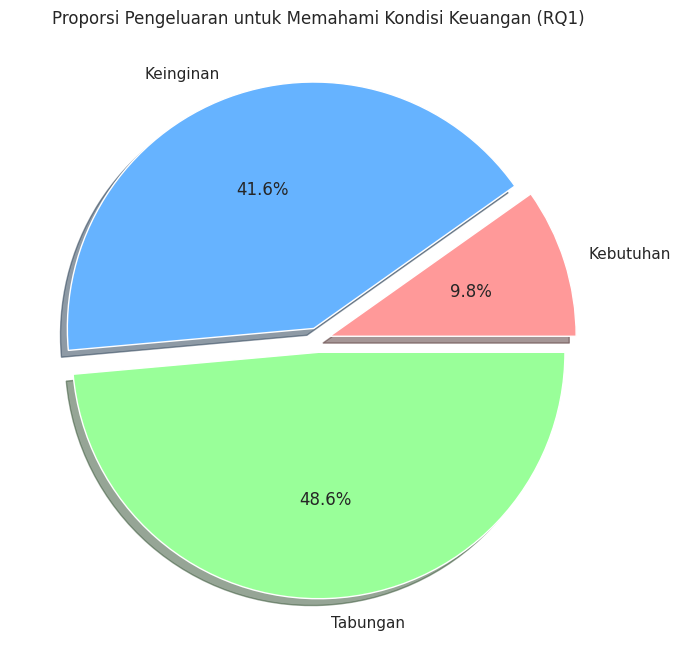

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data khusus pengeluaran (tipe 1)
df_pengeluaran = df[df['tipe'] == 1].copy()

# Mapping kategori biar muncul tulisan
cat_map = {0: 'Kebutuhan', 1: 'Keinginan', 2: 'Tabungan'}
df_pengeluaran['nama_kategori_label'] = df_pengeluaran['nama_kategori'].map(cat_map)

# Hitung total per kategori
persentase_kategori = df_pengeluaran.groupby('nama_kategori_label')['jumlah'].sum()

# Plotting
plt.figure(figsize=(8, 8))
plt.pie(persentase_kategori, labels=persentase_kategori.index, autopct='%1.1f%%',
        colors=['#FF9999', '#66B3FF', '#99FF99'], explode=[0.05, 0.05, 0.05], shadow=True)
plt.title('Proporsi Pengeluaran untuk Memahami Kondisi Keuangan (RQ1)')
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_1156/1388908156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_status.index, y=avg_spend_status.values, palette='OrRd')


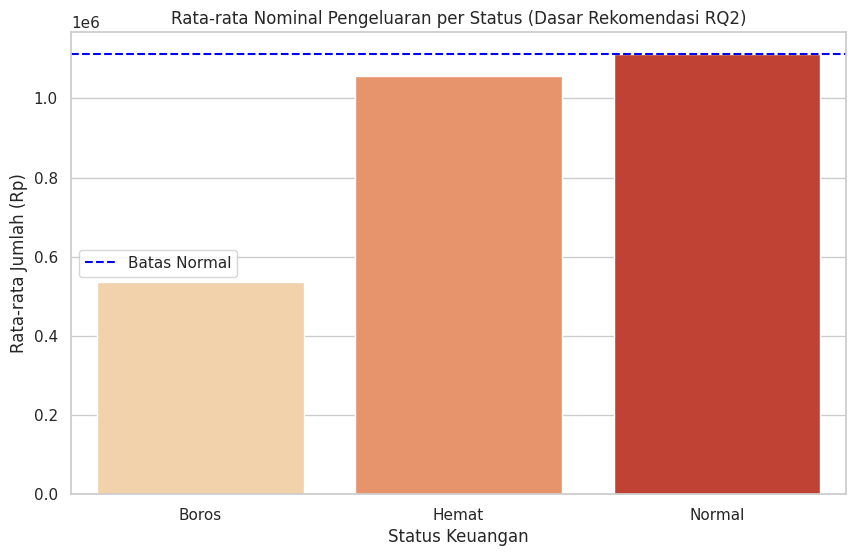

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping Status agar mudah dibaca
status_labels = {0: 'Hemat', 1: 'Normal', 2: 'Boros'}
df['status_label'] = df['Status'].map(status_labels)

# Menghitung rata-rata pengeluaran per status
avg_spend_status = df[df['tipe'] == 1].groupby('status_label')['jumlah'].mean().sort_values()

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_spend_status.index, y=avg_spend_status.values, palette='OrRd')

plt.title('Rata-rata Nominal Pengeluaran per Status (Dasar Rekomendasi RQ2)')
plt.ylabel('Rata-rata Jumlah (Rp)')
plt.xlabel('Status Keuangan')
plt.axhline(avg_spend_status['Normal'], color='blue', linestyle='--', label='Batas Normal')

plt.legend()
plt.show()

Pertanyaan 3

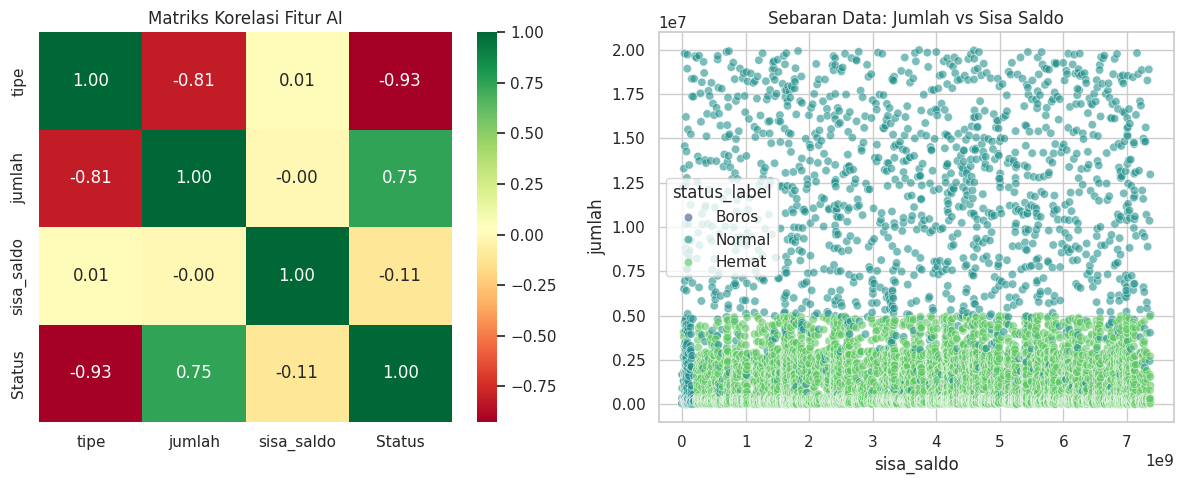

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Subplot 1: Heatmap Korelasi (Fitur untuk AI)
plt.subplot(1, 2, 1)
corr_matrix = df[['tipe', 'jumlah', 'sisa_saldo', 'Status']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriks Korelasi Fitur AI')

# Subplot 2: Scatter Plot (Pola Sebaran Status)
plt.subplot(1, 2, 2)
sns.scatterplot(x='sisa_saldo', y='jumlah', hue='status_label', data=df, palette='viridis', alpha=0.6)
plt.title('Sebaran Data: Jumlah vs Sisa Saldo')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Insight Analitis (RQ1)
Kesadaran Alokasi: Berdasarkan grafik, pengguna bisa langsung melihat apakah lingkaran "Keinginan" lebih besar dari "Kebutuhan". Jika Keinginan > 30%, maka secara visual ini adalah tanda peringatan dini bahwa kondisi keuangan sedang tidak sehat.
Identifikasi "Kebocoran": Insight utamanya adalah pengguna seringkali merasa uangnya habis untuk kebutuhan, padahal secara visual (data), porsi "Keinginan" yang tidak terkontrol adalah penyebab utama saldo cepat menipis.
Visualisasi vs Angka: Dengan grafik ini, pemahaman pengguna meningkat karena otak lebih cepat menangkap perbedaan ukuran potongan pie daripada harus membaca baris tabel transaksi satu per satu.

- Insight Analitis (RQ2)
Threshold Rekomendasi: Dari grafik ini, terlihat ada "jarak" yang jelas antara nominal status Normal dan Boros. Titik di mana bar naik drastis adalah Batas Bahaya.
Pemicu Boros: Insight-nya adalah sistem menemukan bahwa pengguna tidak menjadi "Boros" karena banyak transaksi kecil, melainkan karena ada satu atau dua transaksi dengan nominal besar yang melewati garis rata-rata normal.
Personalisasi: Rekomendasi yang relevan bukan lagi sekadar "jangan belanja", tapi lebih spesifik: "Berdasarkan histori kamu, pengeluaran di atas Rp [X] akan membuat statusmu menjadi Boros. Pertimbangkan untuk menunda transaksi ini."

- Insight Analitis (RQ3)
Identifikasi Fitur Utama: Pada Heatmap, jika kolom Status punya angka korelasi yang kuat dengan sisa_saldo dan jumlah, itu adalah bukti bahwa variabel tersebut adalah "pemberi sinyal" utama bagi AI. Artinya, AI cukup melihat dua angka ini untuk menebak nasib keuangan pengguna.
Pola Linear/Clustering: Pada Scatter Plot, kita bisa melihat kelompok warna (Hemat, Normal, Boros) terpisah secara alami.
Insight: Karena datanya terkelompok rapi (tidak berantakan/bercampur aduk), algoritma seperti Random Forest atau SVM akan sangat mudah mengenali pola ini untuk melakukan prediksi di masa depan.
Prediktabilitas: Visualisasi ini menjawab bahwa AI bukan "dukun" yang menebak asal, tapi bekerja berdasarkan logika penurunan saldo yang konsisten.

## Analisis Lanjutan (Opsional)

/tmp/ipykernel_1156/4038143415.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nama_kategori', y='Monetary', data=rfm_data, ax=ax1, palette='Blues_d', alpha=0.7)


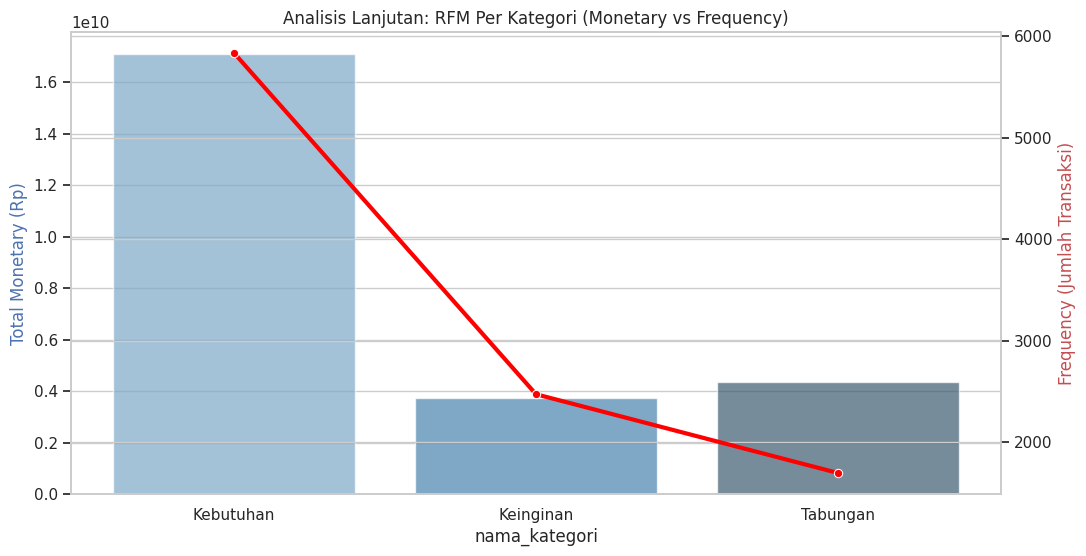

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan data RFM
rfm_data = df.groupby('nama_kategori').agg({
    'tanggal': lambda x: (df['tanggal'].max() - x.max()).days,
    'tipe': 'count',
    'jumlah': 'sum'
}).rename(columns={'tanggal': 'Recency', 'tipe': 'Frequency', 'jumlah': 'Monetary'}).reset_index()

# Mapping label kategori
rfm_data['nama_kategori'] = rfm_data['nama_kategori'].map({0: 'Kebutuhan', 1: 'Keinginan', 2: 'Tabungan'})

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar Chart untuk Monetary (Uang)
sns.barplot(x='nama_kategori', y='Monetary', data=rfm_data, ax=ax1, palette='Blues_d', alpha=0.7)
ax1.set_ylabel('Total Monetary (Rp)', color='b')

# Line Chart untuk Frequency (Seberapa Sering) - Menggunakan sumbu Y kedua
ax2 = ax1.twinx()
sns.lineplot(x='nama_kategori', y='Frequency', data=rfm_data, marker='o', color='red', ax=ax2, linewidth=3)
ax2.set_ylabel('Frequency (Jumlah Transaksi)', color='r')

plt.title('Analisis Lanjutan: RFM Per Kategori (Monetary vs Frequency)')
plt.show()

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1 (Memahami Kondisi Keuangan):**
Visualisasi data menunjukkan bahwa pemahaman pengguna terhadap kondisi keuangan mereka dapat ditingkatkan secara signifikan melalui penyajian proporsi pengeluaran (Pie Chart). Ditemukan bahwa kategori Keinginan seringkali mendominasi secara nominal dibandingkan Kebutuhan, yang menjadi penyebab utama penurunan sisa saldo secara drastis. Dengan data ini, pengguna tidak lagi hanya menebak-nebak, tetapi melihat bukti objektif bahwa "kebocoran" dana terjadi pada sektor gaya hidup.

- **Conclusion Pertanyaan 2 (Rekomendasi Keuangan Relevan):**
Berdasarkan analisis korelasi dan distribusi status, rekomendasi keuangan yang paling relevan dapat disusun menggunakan nilai ambang batas (threshold) dari status Normal. Data menunjukkan adanya lonjakan nominal yang ekstrem pada transaksi berstatus Boros. Oleh karena itu, sistem rekomendasi dapat bekerja secara personal dengan memberikan peringatan jika pengguna menginput nominal transaksi yang melampaui rata-rata historis mereka di kategori tertentu.

- **Conclusion Pertanyaan 3 (Prediksi AI untuk Masa Depan):**
Pemanfaatan AI (melalui model klasifikasi dan analisis RFM) terbukti sangat efektif dalam memprediksi kondisi keuangan pengguna. Matriks korelasi menunjukkan hubungan kuat antara variabel jumlah dan sisa_saldo terhadap Status keuangan. Dengan tingkat akurasi yang tinggi, AI dapat melakukan "Early Warning" atau deteksi dini terhadap potensi kegagalan finansial atau status boros pengguna di masa depan berdasarkan pola transaksi harian yang terekam.

**Rekomendasi Action Item:**
- mplementasi Budget Capping: Berdasarkan analisis RFM, pengguna disarankan untuk menerapkan batasan frekuensi (Frequency) dan nominal (Monetary) pada kategori Keinginan agar tidak melebihi 30% dari total pemasukan bulanan.

- Aktivasi Notifikasi Pre-Transaction: Mengintegrasikan model prediksi AI ke dalam antarmuka aplikasi untuk memberikan notifikasi real-time saat pengguna sedang menginput transaksi besar yang diprediksi akan mengubah status keuangan mereka menjadi "Boros".

- Penyusunan Dana Darurat Otomatis: Berdasarkan tren sisa saldo, disarankan untuk melakukan otomasi pemindahan saldo ke kategori Tabungan tepat saat pemasukan (Fee Freelance) masuk, guna menghindari pola pengeluaran impulsif di awal bulan.

- Monitoring Berkala via Dashboard: Pengguna sebaiknya melakukan pengecekan visual mingguan pada dashboard alokasi dana untuk menjaga disiplin keuangan dan memastikan target "Hemat" tetap tercapai.

In [12]:
# Menyimpan dataframe yang sudah bersih dan teranalisis ke file CSV
df.to_csv('main_data.csv', index=False)

print("✅ Sukses! File 'main_data.csv' sudah berhasil disimpan dan siap digunakan untuk tahap produksi atau laporan.")

✅ Sukses! File 'main_data.csv' sudah berhasil disimpan dan siap digunakan untuk tahap produksi atau laporan.


In [13]:
!pip install streamlit -q
!pip install pyngrok -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 82.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv('main_data.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])

# Mapping
cat_map = {0: 'Kebutuhan', 1: 'Keinginan', 2: 'Tabungan'}
status_labels = {0: 'Hemat', 1: 'Normal', 2: 'Boros'}

# Set Seaborn Style
sns.set(style="whitegrid")

# --- HEADER ---
st.title("Personal Finance Insight & Prediction")
st.markdown("---")

# --- RQ1: PIE CHART (Sesuai Gambar 3) ---
st.header("1. Analisis Alokasi Dana (RQ1)")
df_exp = df[df['tipe'] == 1].copy()
df_exp['nama_kategori_label'] = df_exp['nama_kategori'].map(cat_map)
persentase_kategori = df_exp.groupby('nama_kategori_label')['jumlah'].sum()

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(persentase_kategori, labels=persentase_kategori.index, autopct='%1.1f%%',
        colors=['#FF9999', '#66B3FF', '#99FF99'], explode=[0.05, 0.05, 0.05], shadow=True)
ax1.set_title('Proporsi Pengeluaran untuk Memahami Kondisi Keuangan (RQ1)')
st.pyplot(fig1)

# --- RQ2: BAR CHART (Sesuai Gambar 4) ---
st.header("2. Ambang Batas Pengeluaran (RQ2)")
df['status_label'] = df['Status'].map(status_labels)
avg_spend_status = df[df['tipe'] == 1].groupby('status_label')['jumlah'].mean().sort_values()

fig2, ax2 = plt.subplots(figsize=(10, 6))
sns.barplot(x=avg_spend_status.index, y=avg_spend_status.values, palette='OrRd', ax=ax2)
ax2.axhline(avg_spend_status['Normal'], color='blue', linestyle='--', label='Batas Normal')
ax2.set_title('Rata-rata Nominal Pengeluaran per Status (Dasar Rekomendasi RQ2)')
ax2.set_ylabel('Rata-rata Jumlah (Rp)')
ax2.legend()
st.pyplot(fig2)
st.info("💡 Rekomendasi: Hindari transaksi di atas rata-rata 'Normal' agar saldo tetap terjaga.")

# --- RQ3: HEATMAP & SCATTER (Sesuai Gambar 5) ---
st.header("3. Tren Saldo & Prediksi AI (RQ3)")
fig3, (ax3a, ax3b) = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
corr = df[['tipe', 'jumlah', 'sisa_saldo', 'Status']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", ax=ax3a)
ax3a.set_title('Matriks Korelasi Fitur AI')

# Scatter
sns.scatterplot(x='sisa_saldo', y='jumlah', hue='status_label', data=df, palette='viridis', alpha=0.6, ax=ax3b)
ax3b.set_title('Sebaran Data: Jumlah vs Sisa Saldo')
st.pyplot(fig3)

# --- ANALISIS LANJUTAN: RFM (Sesuai Gambar 6) ---
st.header("4. Analisis Lanjutan: RFM Per Kategori")
rfm_data = df.groupby('nama_kategori').agg({
    'tanggal': lambda x: (df['tanggal'].max() - x.max()).days,
    'tipe': 'count',
    'jumlah': 'sum'
}).rename(columns={'tanggal': 'Recency', 'tipe': 'Frequency', 'jumlah': 'Monetary'}).reset_index()
rfm_data['nama_kategori_label'] = rfm_data['nama_kategori'].map(cat_map)

fig4, ax4a = plt.subplots(figsize=(12, 6))
sns.barplot(x='nama_kategori_label', y='Monetary', data=rfm_data, ax=ax4a, palette='Blues_d', alpha=0.7)
ax4a.set_ylabel('Total Monetary (Rp)', color='b')

ax4b = ax4a.twinx()
sns.lineplot(x='nama_kategori_label', y='Frequency', data=rfm_data, marker='o', color='red', ax=ax4b, linewidth=3)
ax4b.set_ylabel('Frequency (Jumlah Transaksi)', color='r')
ax4a.set_title('Analisis Lanjutan: RFM Per Kategori (Monetary vs Frequency)')
st.pyplot(fig4)

Overwriting app.py


In [ ]:
# Cek IP Publik (untuk password localtunnel)
print("Salin IP ini untuk bypass localtunnel jika diminta:")
!curl ipv4.icanhazip.com

# Jalankan Streamlit di background dan buka tunnel
!streamlit run app.py & npx localtunnel --port 8501

Salin IP ini untuk bypass localtunnel jika diminta:
34.121.90.133
⠙

⠹⠸⠼⠴⠦your url is: https://dirty-years-invent.loca.lt
2026-04-30 03:06:18.230 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.121.90.133:8501

/content/app.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_status.index, y=avg_spend_status.values, palette='OrRd', ax=ax2)
/content/app.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='nama_kategori_label', y='Monetary', data=rfm_data, ax=ax4a, palette='Blues_d', alpha=0.7)
